In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/ryanarajesh/Desktop/QTM 347 Project/medical_insurance.csv')

In [3]:
# df.shape # (100000, 54) 
# df.dtypes
# df.info() #alcohol_freq nulls refer to none

In [4]:
df.describe() # stats for numeric columns

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [5]:
df.describe(include='object') # stats for string columns

,sex,region,urban_rural,education,marital_status,employment_status,smoker,alcohol_freq,plan_type,network_tier
count,100000,100000,100000,100000,100000,100000,100000,69917,100000,100000
unique,3,5,3,6,4,4,3,3,4,4
top,Female,South,Urban,Bachelors,Married,Employed,Never,Occasional,PPO,Silver
freq,49193,28029,60019,27996,53252,55269,69709,45078,35167,40177


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'count': missing, '%': missing_pct}).query('count > 0')


,count,%
alcohol_freq,30083,30.083


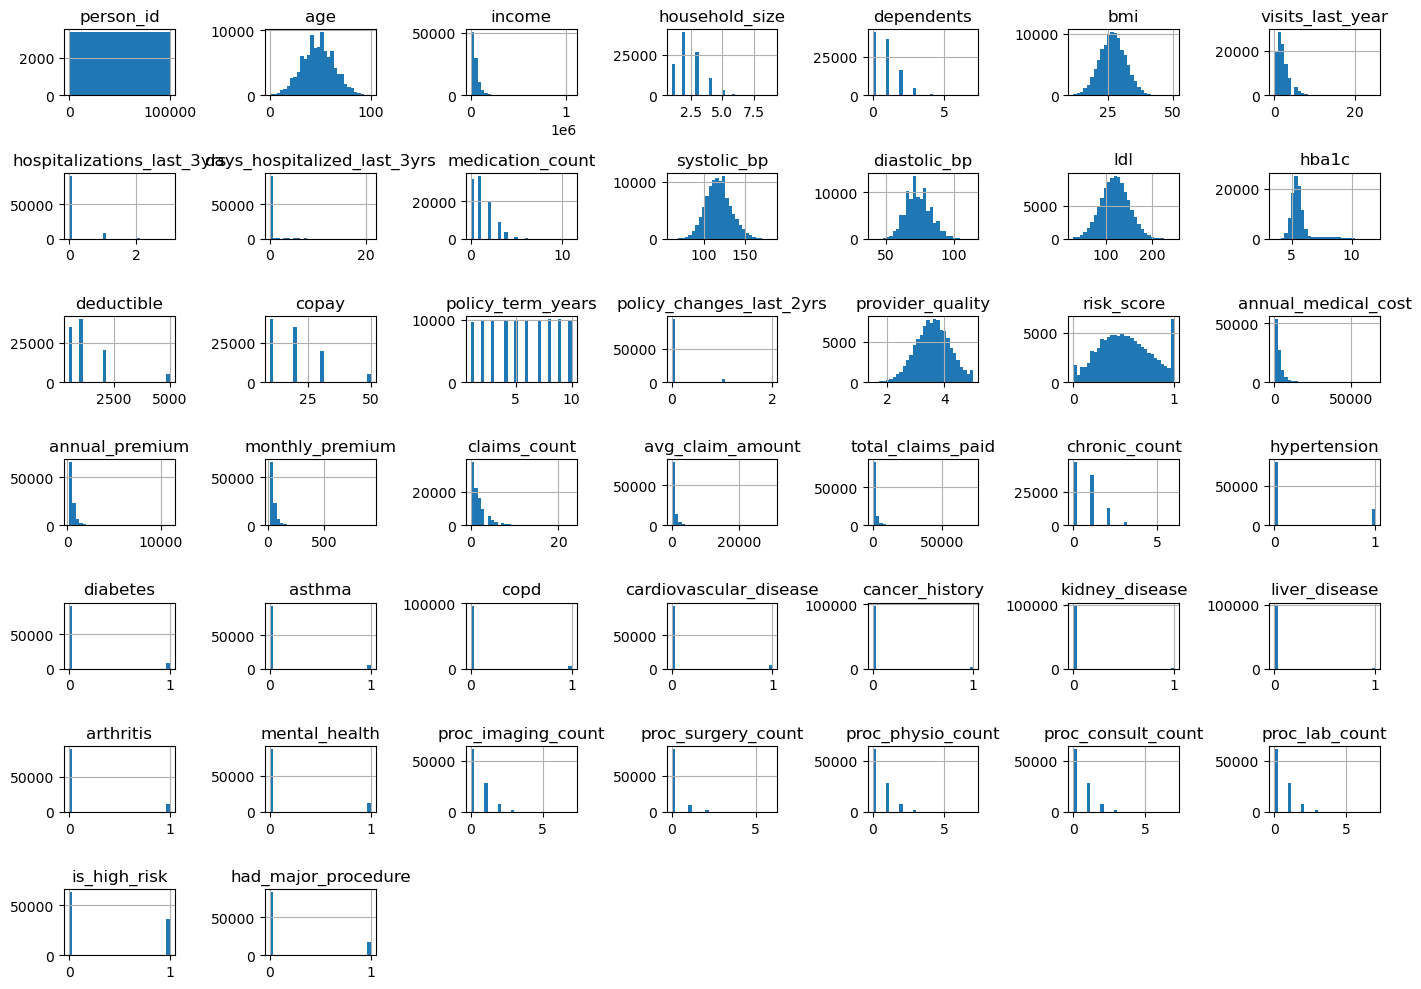

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of every numeric column
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()

In [ ]:

# one-hot encoding for sex - DONE
# one-hot encoding for region - DONE
# urban_rural_clean ordinal for urban-suburban-rural - DONE
# education_clean ordinal for education - DONE
# one-hot encoding for marital_status - DONE
# one-hot encoding for employment_status - DONE
# one-hot encoding for smoker - DONE
# alcohol_freq_clean ordinal for alcohol_freq 0-occasional-weekly-daily - DONE
# one-hot encoding for plan_type - DONE
# one-hot encoding for network_tier - DONE

In [8]:
df_clean = pd.get_dummies(df, columns=['region'])
df_clean = pd.get_dummies(df_clean, columns=['sex'])
df_clean = pd.get_dummies(df_clean, columns=['marital_status'])
df_clean = pd.get_dummies(df_clean, columns=['employment_status'])
df_clean = pd.get_dummies(df_clean, columns=['smoker'])
df_clean = pd.get_dummies(df_clean, columns=['plan_type'])
df_clean = pd.get_dummies(df_clean, columns=['network_tier'])

print(df_clean.head())

   person_id  age urban_rural   income     education  household_size  \
0      75722   52    Suburban  22700.0     Doctorate               3   
1      80185   79       Urban  12800.0         No HS               3   
2      19865   68       Rural  40700.0            HS               5   
3      76700   15    Suburban  15600.0  Some College               5   
4      92992   53    Suburban  89600.0     Doctorate               2   

   dependents   bmi alcohol_freq  visits_last_year  ...  smoker_Former  \
0           1  27.4          NaN                 2  ...          False   
1           1  26.6       Weekly                 2  ...          False   
2           3  31.5          NaN                 1  ...          False   
3           3  31.6          NaN                 0  ...          False   
4           0  30.5        Daily                 3  ...          False   

   smoker_Never  plan_type_EPO  plan_type_HMO  plan_type_POS  plan_type_PPO  \
0          True          False          Fal

In [9]:
mapping1 = {
    'Urban': 0,
    'Suburban': 1,
    'Rural': 2
}

df_clean['urban_rural_clean'] = df_clean['urban_rural'].map(mapping1)

mapping2 = {
    'No HS': 0,
    'HS': 1,
    'Some College': 2,
    'Bachelors': 3,
    'Masters': 4,
    'Doctorate': 5
}

df_clean['education_clean'] = df_clean['education'].map(mapping2)

mapping3 = {
    'Occasional': 1,
    'Weekly': 2,
    'Daily': 3
}

df_clean['alcohol_freq_clean'] = (
    df_clean['alcohol_freq']
    .map(mapping3)
    .fillna(0)
)

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['age', 'sex_Male', 'sex_Female', 'sex_Other', 'region_North', 'region_South', 'region_Central', 'region_East', 'region_West', 
        'urban_rural_clean','income', 'education_clean', 'marital_status_Married', 'marital_status_Single', 'marital_status_Divorced', 
        'marital_status_Widowed', 'employment_status_Retired', 'employment_status_Employed', 
        'employment_status_Self-employed', 'employment_status_Unemployed', 'household_size', 'dependents', 'bmi',
        'smoker_Never', 'smoker_Current', 'smoker_Former', 'alcohol_freq_clean', 'visits_last_year', 
        'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp',
        'ldl', 'hba1c', 'plan_type_PPO', 'plan_type_POS', 'plan_type_HMO', 'plan_type_EPO', 
        'network_tier_Bronze', 'network_tier_Silver', 'network_tier_Gold', 'network_tier_Platinum',
        'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
        'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid',
        'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history',
        'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count',
        'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure'
        ]  

correlation_matrix = df_clean[cols].corr()
print(correlation_matrix)

                          age  sex_Male  sex_Female  sex_Other  region_North  \
age                  1.000000  0.002570   -0.001729  -0.002992     -0.006025   
sex_Male             0.002570  1.000000   -0.960534  -0.139914      0.000490   
sex_Female          -0.001729 -0.960534    1.000000  -0.141035      0.000012   
sex_Other           -0.002992 -0.139914   -0.141035   1.000000     -0.001787   
region_North        -0.006025  0.000490    0.000012  -0.001787      1.000000   
...                       ...       ...         ...        ...           ...   
proc_physio_count    0.017710  0.002855   -0.001050  -0.006422     -0.003691   
proc_consult_count   0.023093  0.001082   -0.002640   0.005548      0.003297   
proc_lab_count       0.025933  0.001280   -0.000856  -0.001508     -0.003596   
is_high_risk         0.559152  0.005978   -0.005130  -0.003012     -0.003390   
had_major_procedure  0.020959 -0.003056    0.003834  -0.002771      0.007715   

                     region_South  regi

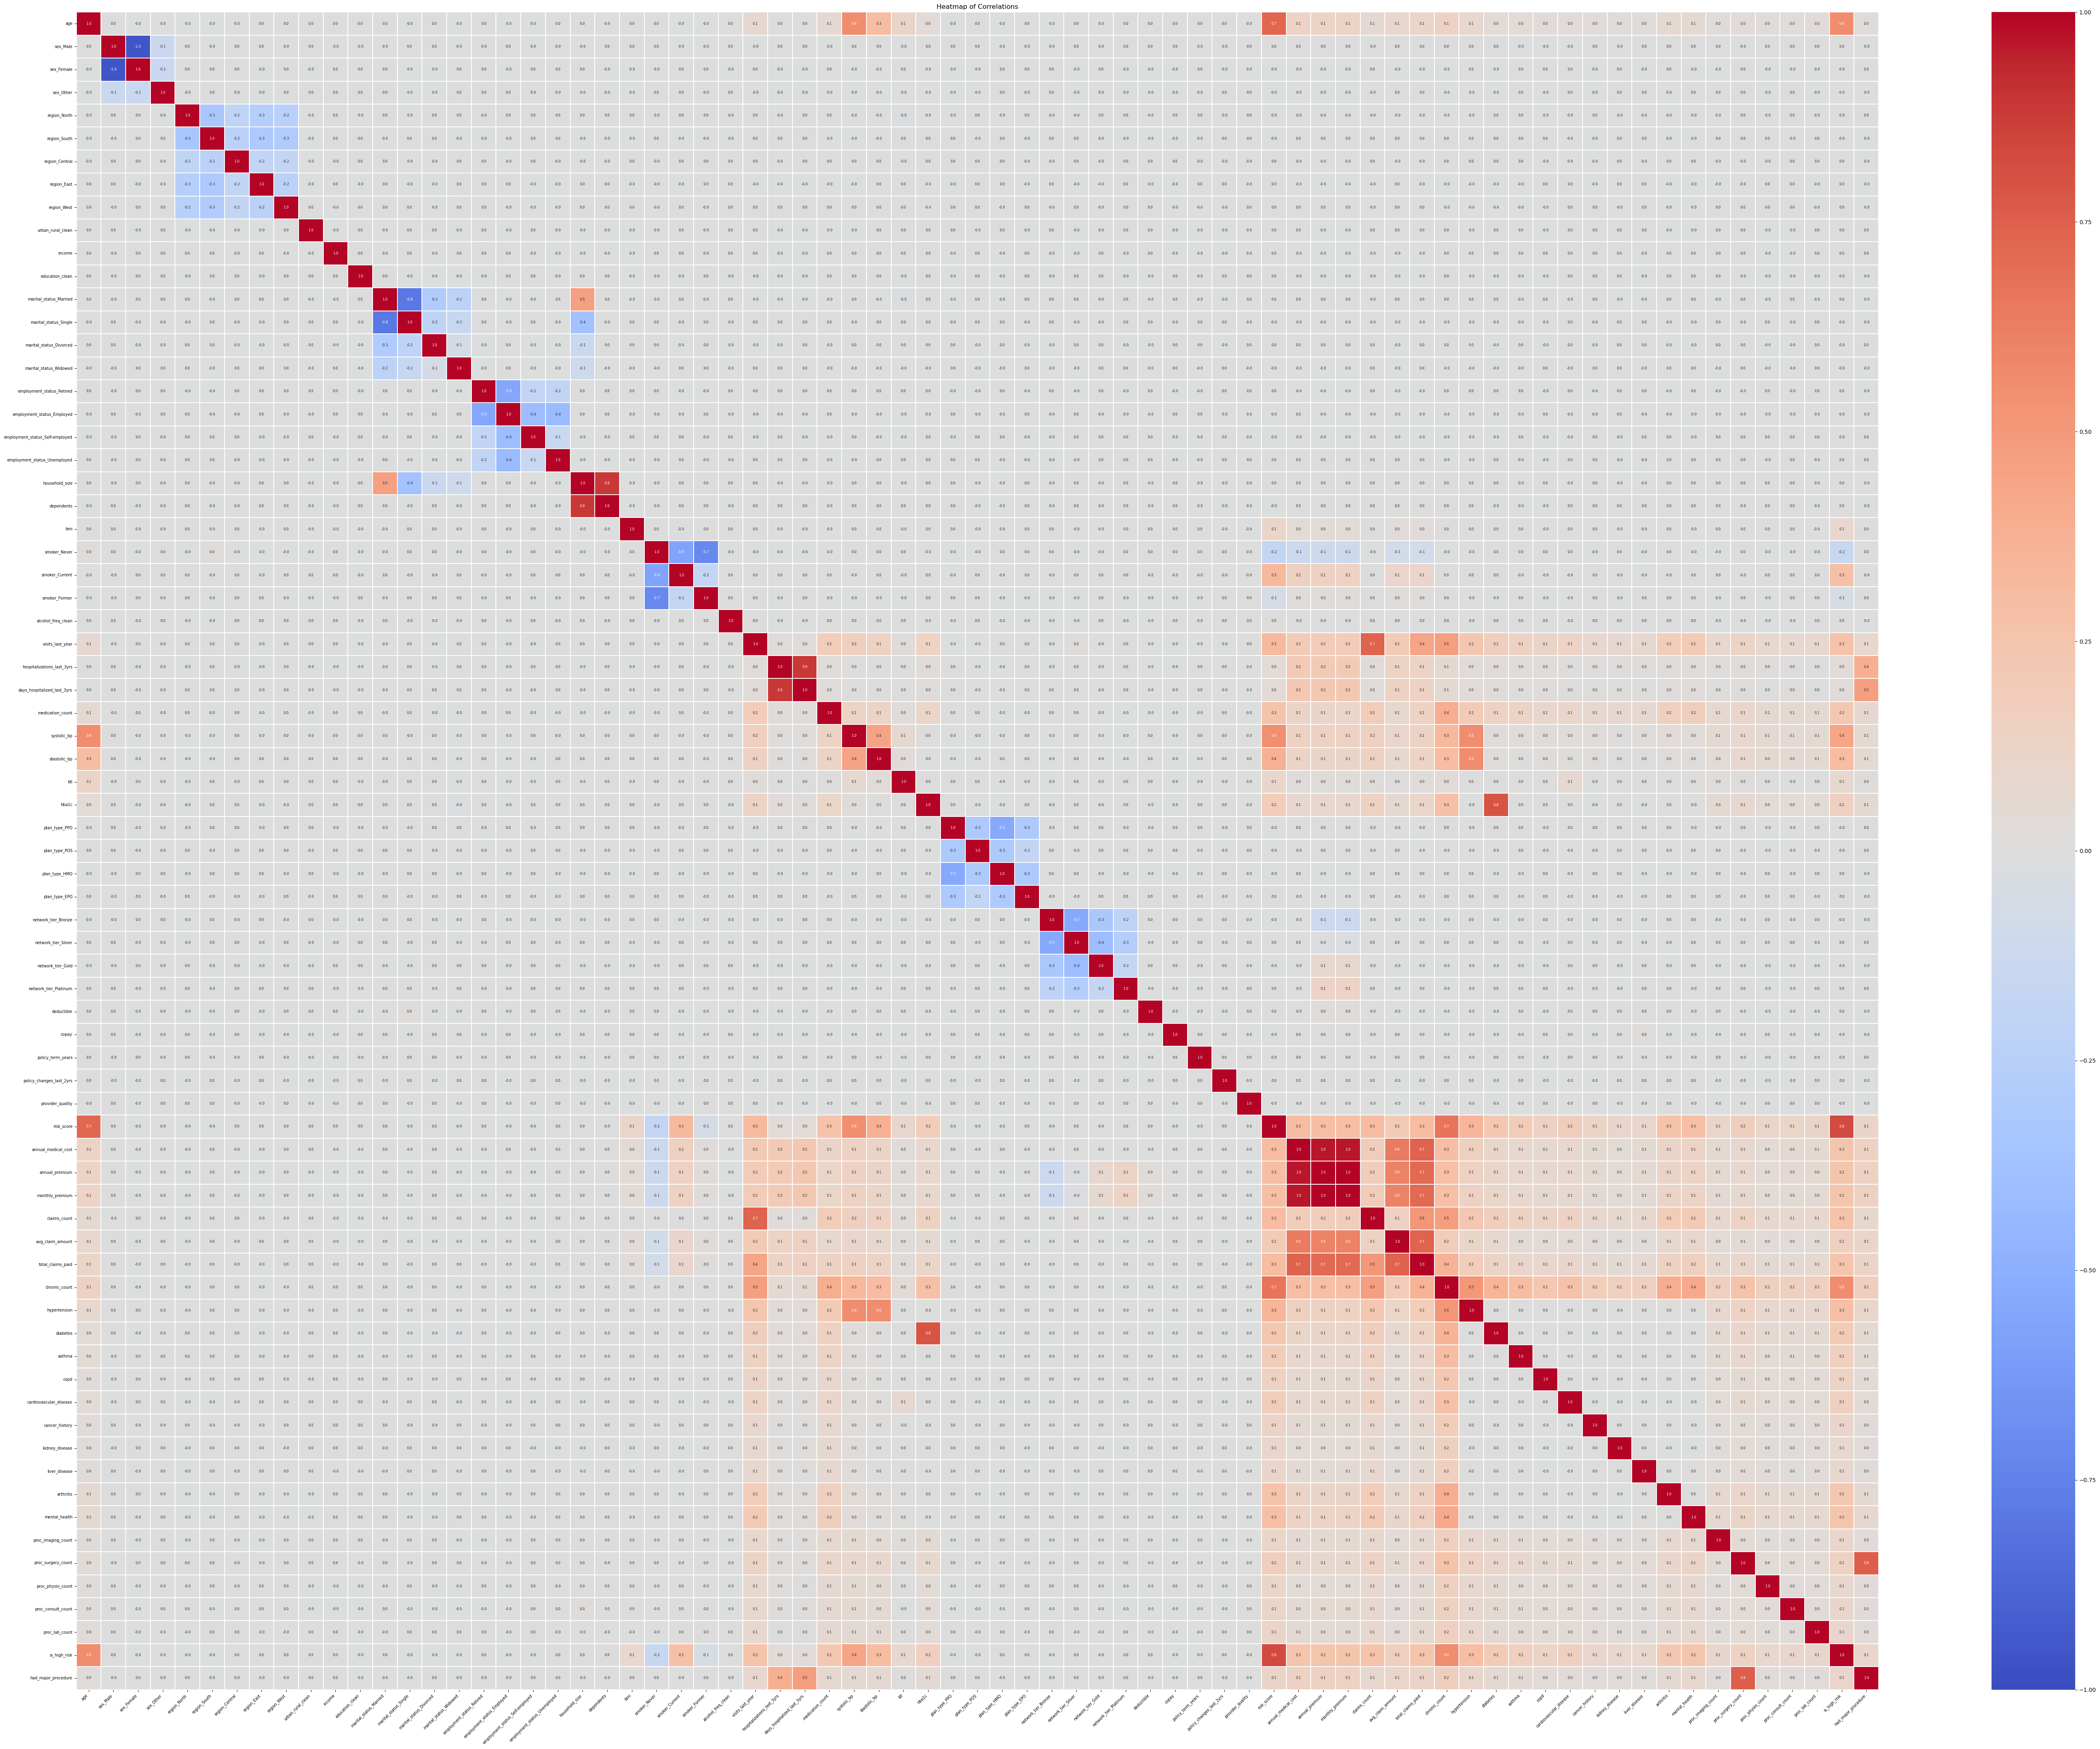

In [11]:
n = len(correlation_matrix.columns)

plt.figure(figsize=(n * 0.8, n * 0.6))   

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.1f',      
    annot_kws={'size': 6},  
    cmap='coolwarm',
    linewidths=0.3,
    vmin=-1, vmax=1
)

plt.title('Heatmap of Correlations')
plt.xticks(rotation=45, ha='right', fontsize=7)   
plt.yticks(rotation=0, fontsize=7)     
plt.tight_layout()
plt.show()

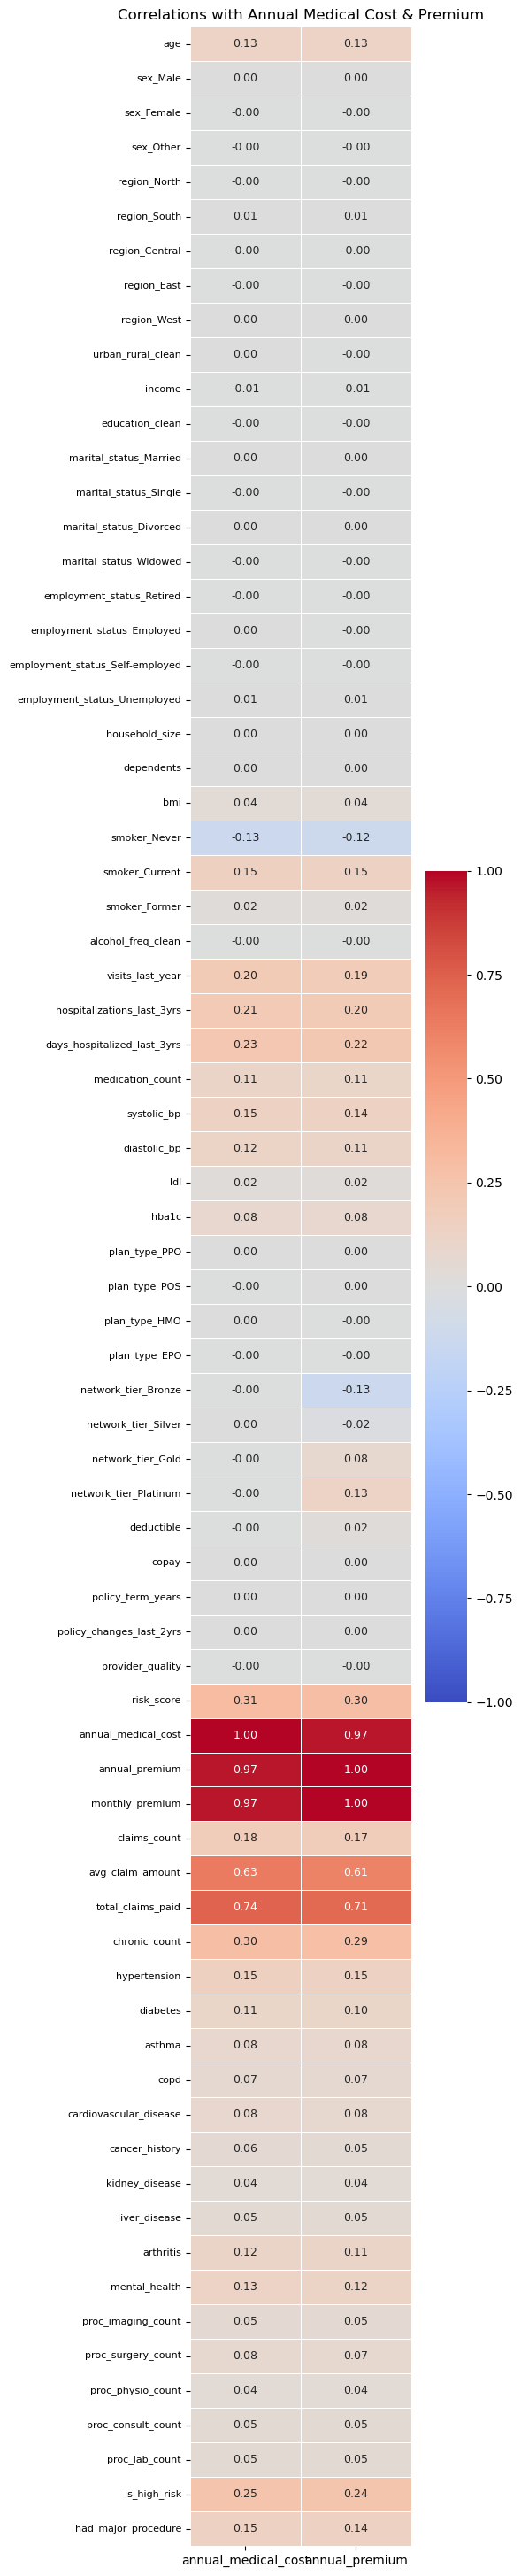

In [12]:
cols_of_interest = ['annual_medical_cost', 'annual_premium']

filtered_corr = correlation_matrix[cols_of_interest]

plt.figure(figsize=(6, len(filtered_corr) * 0.4))  # tall and narrow

sns.heatmap(
    filtered_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Correlations with Annual Medical Cost & Premium')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# Clean and final dataset for modeling
df_model = df_clean.copy()
df_model = df_model.drop(columns=['urban_rural', 'education', 'alcohol_freq'])


# X is our inputs (features) and y is our target (annual_medical_cost)
# First we will try to predict annual medical cost
X = df_model.drop(columns=['annual_medical_cost', 'annual_premium'])
y = df_model['annual_medical_cost']

# annual_medical_cost is extremely right-skewed, so we will log-transform it for modeling
y = np.log1p(y)

In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123
)

In [16]:
# Baseline Model (Trial 1)

#lr = LinearRegression()
#lr.fit(X_train, y_train)

#y_pred_lr = lr.predict(X_test)

#rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
#r2_lr = r2_score(y_test, y_pred_lr)

#print("Linear Regression RMSE:", rmse_lr)
#print("Linear Regression R2:", r2_lr)

In [17]:
# Random Forest Model (Trial 1)

#rf = RandomForestRegressor(
   # n_estimators=200,
   # max_depth=12,
    #random_state=123,
    #n_jobs=-1
#)

#rf.fit(X_train, y_train)

#y_pred_rf = rf.predict(X_test)

#rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
#r2_rf = r2_score(y_test, y_pred_rf)

#print("Random Forest RMSE:", rmse_rf)
#print("Random Forest R2:", r2_rf)

This might be showing data leakage as there may be features that directly encode the target since ~100% of the variance seems to be explained.

We drop the following variables as they are directly related to medical costs and claims:
    annual_medical_cost (target)
    annual_premium
    monthly_premium
    avg_claim_amount
    total_claims_paid

We also dropped all the insurance design variables since they describe the insurance plan structure rather than patient medical need. Including them shifts the model toward learning insurance pricing rather than the overall medical costs.
    plan_type
    network_tier
    policy_term_years
    policy_changes_last_2yrs

We also removed the raw categorical duplicates since after one-hot encoding, the raw categorical variables were redundant and could be read as duplicates.
    sex
    region
    marital status
    employment status
    smoker status
    education


In [18]:
model_cols = [
    # demographics
    'age','sex_Male','sex_Female','sex_Other',
    'region_North','region_South','region_Central','region_East','region_West',
    'urban_rural_clean','income','education_clean',
    'marital_status_Married','marital_status_Single',
    'marital_status_Divorced','marital_status_Widowed',
    'employment_status_Retired','employment_status_Employed',
    'employment_status_Self-employed','employment_status_Unemployed',
    'household_size','dependents',

    # health status
    'bmi',
    'smoker_Never','smoker_Current','smoker_Former',
    'alcohol_freq_clean',
    'systolic_bp','diastolic_bp','ldl','hba1c',
    'chronic_count','hypertension','diabetes','asthma','copd',
    'cardiovascular_disease','cancer_history',
    'kidney_disease','liver_disease','arthritis','mental_health',
    'is_high_risk',

    # utilization
    'visits_last_year',
    'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs',
    'medication_count',
    'proc_imaging_count',
    'proc_surgery_count',
    'proc_physio_count',
    'proc_consult_count',
    'proc_lab_count',
    'claims_count',
    #'total_claims_paid',

    # cost-sharing mechanisms
    'deductible',
    'copay'
]

X = df_model[model_cols]
y = np.log1p(df_model['annual_medical_cost'])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

In [20]:
# Mean Baseline Model 
baseline_value = y_train.mean()
baseline_pred = np.full(len(y_test), baseline_value)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

Baseline RMSE: 0.8476615889730561
Baseline R2: -7.237517684433037e-05


In [ ]:
# Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("LR RMSE:", rmse_lr)
print("LRR2:", r2_lr)


RMSE: 0.7521871029745647
R2: 0.21252243707613405


In [ ]:
# Random Forest Model
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=123,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)



RMSE: 0.7524131243439695
R2: 0.2120491146868787


In [ ]:
# Bagging Model
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=123,
    n_jobs=-1
)

bag.fit(X_train, y_train)

pred_bag = bag.predict(X_test)

rmse_bag = np.sqrt(mean_squared_error(y_test, pred_bag))
r2_bag = r2_score(y_test, pred_bag)

print("Bagging RMSE:", rmse_bag)
print("BaggingR2:", r2_bag)

RMSE: 0.7600290427706173
R2: 0.19601712281882633


In [36]:
# Gradient Boosting Model

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=123
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting RMSE:", rmse_gbr)
print("Gradient Boosting R2:", r2_gbr)

Gradient Boosting RMSE: 0.7506546205652622
Gradient Boosting R2: 0.21572793252925193


In [37]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Bagging",
        "Gradient Boosting"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_bag,
        rmse_gbr
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_bag,
        r2_gbr
    ]
})

print("\nMODEL COMPARISON TABLE")
print(results.round(3))


MODEL COMPARISON TABLE
               Model   RMSE     R2
0  Linear Regression  0.752  0.213
1      Random Forest  0.752  0.212
2            Bagging  0.760  0.196
3  Gradient Boosting  0.751  0.216


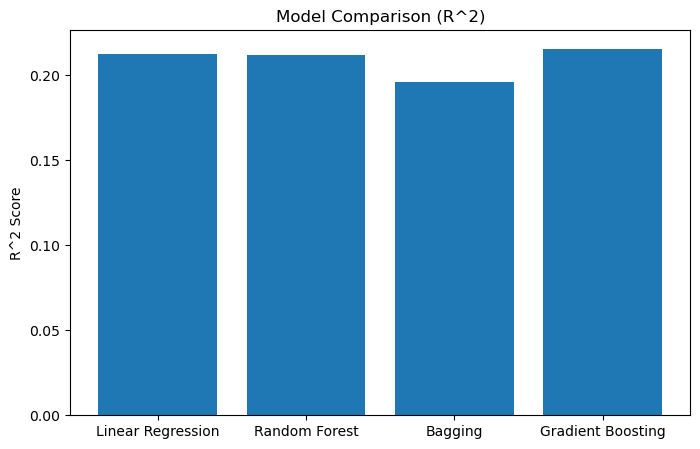

In [43]:
models = ["Linear Regression", "Random Forest", "Bagging", "Gradient Boosting"]

r2_scores = [r2_lr, r2_rf, r2_bag, r2_gbr]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title("Model Comparison (R^2)")
plt.ylabel("R^2 Score")


plt.show()


TOP RANDOM FOREST FEATURES
chronic_count                  0.410417
days_hospitalized_last_3yrs    0.152965
smoker_Current                 0.074724
age                            0.067787
is_high_risk                   0.054881
bmi                            0.038205
ldl                            0.022975
income                         0.020272
hba1c                          0.018676
visits_last_year               0.017809
systolic_bp                    0.015602
diastolic_bp                   0.014182
smoker_Never                   0.013670
smoker_Former                  0.007112
claims_count                   0.007096
dtype: float64


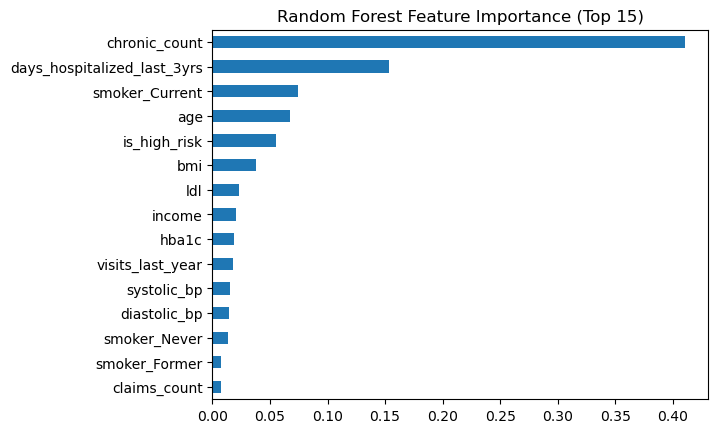

In [32]:
# Top 15 most important features based on Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\nTOP RANDOM FOREST FEATURES")
print(importances.head(15))

importances.head(15).plot(kind='barh')
plt.title("Random Forest Feature Importance (Top 15)")
plt.gca().invert_yaxis()
plt.show()

chronic_count                  0.400263
days_hospitalized_last_3yrs    0.183454
is_high_risk                   0.180314
smoker_Current                 0.061339
age                            0.049142
smoker_Never                   0.045501
visits_last_year               0.033267
bmi                            0.021125
hospitalizations_last_3yrs     0.011908
income                         0.003222
hba1c                          0.001943
ldl                            0.001660
systolic_bp                    0.001216
diastolic_bp                   0.001144
claims_count                   0.000715
dtype: float64


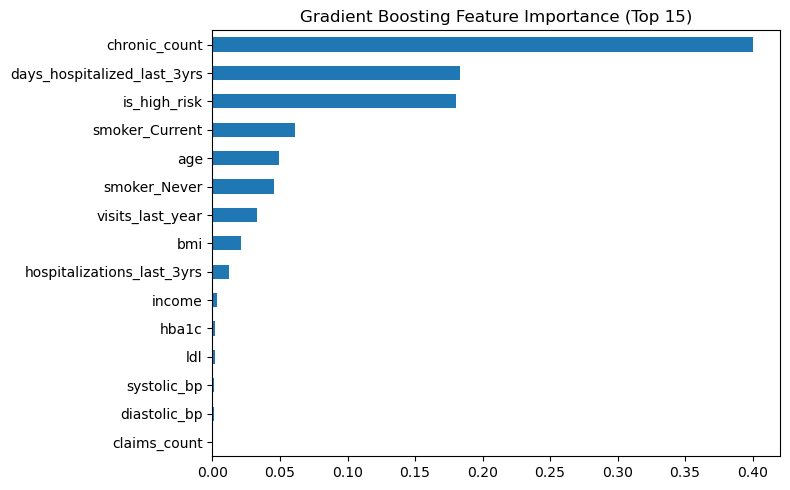

In [44]:
#Top 15 most important features based on Gradient Boosting
importances = pd.Series(gbr.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

print(importances_sorted.head(15))

plt.figure(figsize=(8,5))
importances_sorted.head(15).plot(kind='barh')

plt.title("Gradient Boosting Feature Importance (Top 15)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Linear Regression CV R2: 0.21220942359430167
Linear Regression CV Std: 0.00409604308296245

Random Forest CV R2: 0.21384505039573581
Random Forest CV Std: 0.005201607667136397
Gradient Boosting CV R2: 0.21768256002106395
Gradient Boosting CV Std: 0.005716572283532682


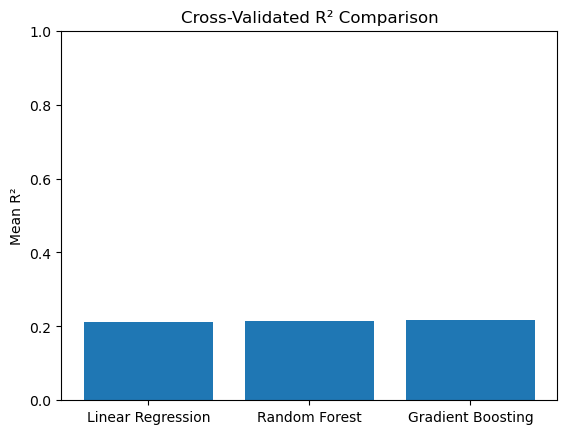

In [ ]:
# Cross Validation for Top 2 Models

# Linear Regression Cross Validation
lr_cv = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Linear Regression CV R2:", lr_cv.mean())
print("Linear Regression CV Std:", lr_cv.std())

# Random Forest Cross Validation
rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Random Forest CV R2:", rf_cv.mean())
print("Random Forest CV Std:", rf_cv.std())

# Gradient Boosting Cross Validation
gbr_cv = cross_val_score(
    gbr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Gradient Boosting CV R2:", gbr_cv.mean())
print("Gradient Boosting CV Std:", gbr_cv.std())

models = ["Linear Regression", "Random Forest", "Gradient Boosting"]
scores = [lr_cv.mean(), rf_cv.mean(), gbr_cv.mean()]

plt.bar(models, scores)
plt.title("Cross-Validated R² Comparison")
plt.ylabel("Mean R²")
plt.ylim(0, 1)
plt.show()

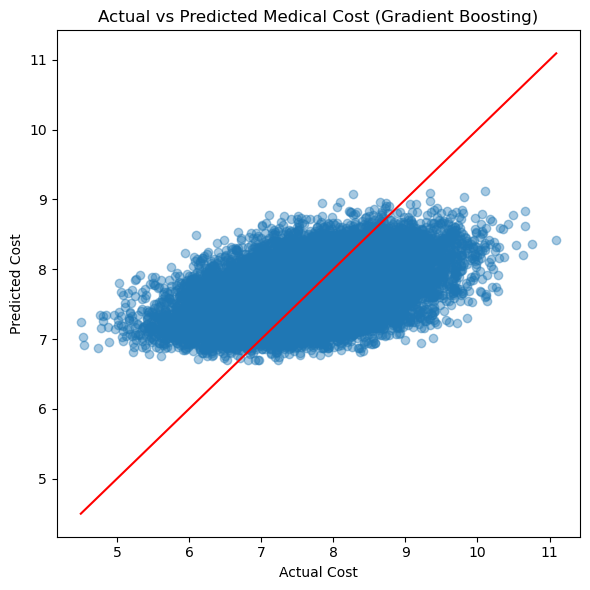

In [ ]:
y_pred_gbr = gbr.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_gbr, alpha=0.4)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted Medical Cost (Gradient Boosting)")
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")

plt.tight_layout()
plt.show()